# H-003 · Idiosyncratic Vol Rank

Factor test for **H-003** (equities): whether stocks with **lower** idiosyncratic volatility earn higher next-week returns (idiosyncratic volatility puzzle).

- **Idea** — Rank names by stock-specific return noise after stripping out market (SPY) exposure.
- **Claim** — Low idio-vol rank predicts higher forward returns; high rank predicts lower returns.
- **Why it might work** — Lottery preference and short-sale constraints can leave high idio-vol names overpriced; mispricing is easier to arbitrage in quieter names.
- **Data** — Daily OHLCV long panel + SPY daily returns (benchmark locked to SPY).

## What is idiosyncratic volatility (`idio_vol`)?

**Idiosyncratic volatility** is the volatility of a stock's returns *after removing market exposure*, not total realised vol.

1. Fit rolling OLS on daily log returns: `r_{i,t} = alpha + beta * r_{SPY,t} + epsilon_t`
2. Collect in-window residuals `epsilon_t`
3. **`idio_vol`** = sample std (`ddof=1`) of those residuals over the window (default 20 days)

This is **stock-specific noise** — moves not explained by the market — as opposed to beta-linked risk.

## Raw `idio_vol` vs the H-003 factor signal

| Object | What it is |
|--------|------------|
| **`idio_vol`** (raw) | Rolling residual std from the beta regression; an intermediate datum |
| **H-003 factor** | Cross-sectional percentile rank of `idio_vol` on each date |

The S1 factor panel notebook attaches **beta foundation columns only** (`alpha`, `beta`, `r2`). Idio vol is built here via modular helpers — not inline in the panel notebook — so research, walk-forward, and live code share the same implementation.

- Rolling OLS primitives: `data.processing.feature_implementation.beta`
- Idio vol series/panel helpers: `data.processing.feature_implementation.idiosyncratic_vol`
- Future store entrypoint (planned): `add_idiosyncratic_vol` in `feature_store` with `normalize=True` (CS pct-rank by default)

**Per-day residuals (`epsilon_t`):** `epsilon_t = r_{i,t} - alpha_t - beta_t * r_{SPY,t}`. Not stored in the panel by default; `idio_vol` summarizes their dispersion over the window. Per-day residuals could later support abnormal-return event studies, residual momentum, or conditional vol models.

## 0. Imports & Config

Resolve repo root; configure `window` (default 20), SPY benchmark dates, and `normalize` for the eventual store call. Import `fetch_ohlcv`, `fetch_top_n_equities`, `add_idiosyncratic_vol`, and `market_return_frame`.

In [11]:
import os
import sys

import alphalens as al
import pandas as pd

from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.cleaner import forward_fill_panel
from data.processing.feature_implementation.beta import market_return_frame
from data.processing.feature_implementation.gk_vol_ratio import add_realised_vol
from data.processing.feature_implementation.obv_momentum import cross_sectional_pct_rank
from data.processing.feature_store import add_idiosyncratic_vol

# Jupyter cwd is often this notebook's folder, not the repo root; walk up until we find 01_data/ingestion.
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

TRAIN_PANEL_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_factor_panel_train.parquet"
)

# --- Window screen (edit this list) ---
WINDOWS = [10, 20, 63]  # W — each tested for idio_vol and realised_vol baselines

# --- Fixed for this notebook ---
NORMALIZE = True         # fixed
PERIODS = (1, 5, 21)     # fixed — H-003 / S1 default; primary narrative = 5d
QUANTILES = 5
MAX_LOSS = 0.35
BENCHMARK = "SPY"        # fixed


## 1. Data Loading

Load daily OHLCV long panel (PIT universe) and SPY benchmark via project fetchers only.

- `fetch_top_n_equities` or saved `s1_factor_panel_train.parquet` for OHLCV (+ optional beta columns)
- `fetch_ohlcv("SPY", ...)` for market returns

In [12]:
panel = pd.read_parquet(TRAIN_PANEL_PATH)
required = {"date", "ticker", "close"}
missing = required - set(panel.columns)
if missing:
    raise ValueError(f"train panel missing columns: {sorted(missing)}")

panel = panel.copy()
panel["date"] = pd.to_datetime(panel["date"])

# Buffer past panel end so Alphalens can compute 21d forward returns near the last IS date.
start = panel["date"].min().strftime("%Y-%m-%d")
end = (panel["date"].max() + pd.Timedelta(days=40)).strftime("%Y-%m-%d")
spy = fetch_ohlcv(BENCHMARK, start, end)
market_returns = market_return_frame(spy)

print(f"rows={len(panel):,}  tickers={panel['ticker'].nunique():,}  "
      f"dates={panel['date'].nunique():,}  "
      f"[{panel['date'].min().date()} → {panel['date'].max().date()}]")
print(f"SPY market returns: {len(market_returns):,} rows")
panel.head()


rows=115,000  tickers=100  dates=1,150  [2020-01-02 → 2024-07-29]
SPY market returns: 1,178 rows


,date,ticker,open,high,low,close,volume
0,2020-01-02,AAPL,71.3441,72.3941,71.0912,72.3339,135480400
1,2020-01-02,ABBV,67.8527,68.2260,67.4185,68.2107,5639200
2,2020-01-02,ABT,75.9952,76.7900,75.7656,76.7811,4969000
3,2020-01-02,ACN,189.2654,190.2168,187.4253,188.6281,2431100
4,2020-01-02,ADBE,330.0000,334.4800,329.1700,334.4300,1990100


## 2. Data Cleaning & Engineering

Build market log returns; attach raw `idio_vol` via `add_idiosyncratic_vol` (uses beta OLS under the hood).

Any winsorize / floor lives here — the library modules do **not** floor or winsorize by default.

In [13]:
panel = forward_fill_panel(panel, columns=["close"], limit=5)
panel = panel.dropna(subset=["close"]).reset_index(drop=True)
print(f"after clean: rows={len(panel):,}  null close={panel['close'].isna().sum()}")


after clean: rows=115,000  null close=0


## 3. Modeling / Signal Construction

Transform raw `idio_vol` into the H-003 factor: cross-sectional percentile rank within each date.

When implemented in `feature_store`, expect column `idio_vol_rank` (or similar mode name) with `normalize=True` by default.

In [14]:
def add_cs_ranked_realised_vol(
    panel: pd.DataFrame,
    *,
    realised_window: int,
) -> pd.DataFrame:
    """Add CS pct-ranked realised vol as ``realised_vol_{W}`` (baseline)."""
    tmp = f"_realised_vol_tmp_{realised_window}"
    out_col = f"realised_vol_{realised_window}"
    out = add_realised_vol(panel, realised_window=realised_window, col=tmp)
    out[out_col] = cross_sectional_pct_rank(out, tmp)
    return out.drop(columns=[tmp])


In [15]:
panel = add_idiosyncratic_vol(
    panel,
    market_returns,
    windows=WINDOWS,
    normalize=NORMALIZE,
)

IDIO_COLS = [c for c in panel.columns if c.startswith("idio_vol")]
REALISED_COLS = []
for w in WINDOWS:
    panel = add_cs_ranked_realised_vol(panel, realised_window=w)
    REALISED_COLS.append(f"realised_vol_{w}")

FACTOR_COLS = IDIO_COLS + REALISED_COLS
print(f"Idio factors ({len(IDIO_COLS)}): {IDIO_COLS}")
print(f"Realised baselines ({len(REALISED_COLS)}): {REALISED_COLS}")


Idio factors (3): ['idio_vol_10', 'idio_vol_20', 'idio_vol_63']
Realised baselines (3): ['realised_vol_10', 'realised_vol_20', 'realised_vol_63']


## 4. Evaluation

Quintile spread and IC of idio-vol rank vs 5-day forward return; compare to total realised vol rank as baseline. Expect negative monotonicity (low rank → long). Use purge/embargo for overlapping 5d labels.

### 4.1 Window screen summary

Factor column names encode kind and window. Each `W` in `WINDOWS` is tested for both idio-vol rank and realised-vol rank.

| Token | Meaning | Formula / role |
|-------|---------|----------------|
| **W** | Rolling window length | Days in the residual-std / realised-vol window ending at `t` |
| `idio_vol_{W}` | H-003 factor | CS pct-rank of residual std vs SPY over W (expect **negative** IC) |
| `realised_vol_{W}` | Baseline | CS pct-rank of close-to-close realised vol over W |

Primary ranking metric below: **mean IC at 5d** (`ic_5d`).


In [16]:
def to_alphalens_prices(panel: pd.DataFrame) -> pd.DataFrame:
    """Wide close matrix for Alphalens only (dates × tickers)."""
    prices = panel.pivot(index="date", columns="ticker", values="close")
    prices.index = pd.to_datetime(prices.index)
    return prices.sort_index()


def to_alphalens_factor(panel: pd.DataFrame, col: str) -> pd.Series:
    """MultiIndex (date, ticker) factor series for Alphalens."""
    factor = panel.set_index(["date", "ticker"])[col].dropna()
    factor.index = factor.index.set_levels(
        pd.to_datetime(factor.index.levels[0]), level=0
    )
    return factor.sort_index()


def parse_factor_name(col: str) -> dict:
    """Decode ``idio_vol_{W}`` or ``realised_vol_{W}``."""
    if col.startswith("idio_vol_"):
        return {"kind": "idio", "W": int(col.rsplit("_", 1)[-1])}
    if col.startswith("realised_vol_"):
        return {"kind": "realised", "W": int(col.rsplit("_", 1)[-1])}
    if col == "idio_vol":
        return {"kind": "idio", "W": pd.NA}
    if col == "realised_vol":
        return {"kind": "realised", "W": pd.NA}
    raise ValueError(f"unrecognized factor column: {col!r}")


def _period_label(period_index: pd.Index, period: int, position: int):
    """Match Alphalens period label ('1D', '5D', …) or fall back by position."""
    for c in (f"{period}D", f"{period}d", period, str(period)):
        if c in period_index:
            return c
    return period_index[position]


def factor_screen_metrics(
    factor: pd.Series,
    prices: pd.DataFrame,
    *,
    periods: tuple[int, ...] = PERIODS,
    quantiles: int = QUANTILES,
    max_loss: float = MAX_LOSS,
) -> dict:
    """Mean IC and Q5−Q1 mean return spread for each forward period."""
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=factor,
        prices=prices,
        quantiles=quantiles,
        periods=periods,
        max_loss=max_loss,
    )
    mean_ic = al.performance.mean_information_coefficient(factor_data)
    mean_ret, _ = al.performance.mean_return_by_quantile(factor_data, demeaned=True)

    row = {}
    for i, p in enumerate(periods):
        ic_key = _period_label(mean_ic.index, p, i)
        ret_key = _period_label(mean_ret.columns, p, i)
        row[f"ic_{p}d"] = float(mean_ic.loc[ic_key])
        q_hi, q_lo = mean_ret.index.max(), mean_ret.index.min()
        row[f"spread_{p}d"] = float(
            mean_ret.loc[q_hi, ret_key] - mean_ret.loc[q_lo, ret_key]
        )
    return row


In [17]:
prices = to_alphalens_prices(panel)

rows = []
for col in FACTOR_COLS:
    meta = parse_factor_name(col)
    metrics = factor_screen_metrics(to_alphalens_factor(panel, col), prices)
    rows.append({"factor": col, **meta, **metrics})

summary = (
    pd.DataFrame(rows)
    .sort_values("ic_5d", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
summary


Dropped 1.8% entries from factor data: 1.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.8% entries from factor data: 1.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 1.9% en

,factor,kind,W,ic_1d,spread_1d,ic_5d,spread_5d,ic_21d,spread_21d
0,realised_vol_63,realised,63,-0.0002,0.0006,0.0122,0.0033,0.0306,0.0139
1,idio_vol_20,idio,20,-0.0017,0.0006,0.0099,0.0028,0.0293,0.0117
2,realised_vol_20,realised,20,-0.0034,0.0004,0.0092,0.0022,0.0277,0.0100
3,realised_vol_10,realised,10,-0.0037,0.0004,0.0079,0.0020,0.0241,0.0092
4,idio_vol_10,idio,10,-0.0044,0.0005,0.0061,0.0025,0.0259,0.0104
5,idio_vol_63,idio,63,-0.0018,0.0004,0.0061,0.0019,0.0178,0.0084


### 4.2 Full tear sheet (manual combo)

Review the summary table in §4.1, then set `TEAR_KIND` and `TEAR_WINDOW` in the cell below. The tear sheet runs on `idio_vol_{W}` or `realised_vol_{W}` for those values — nothing is auto-selected.


In [18]:
def tear_factor_col(kind: str, window: int) -> str:
    """Column name for tear sheet: ``idio_vol_{W}`` or ``realised_vol_{W}``."""
    if kind == "idio":
        return f"idio_vol_{window}"
    if kind == "realised":
        return f"realised_vol_{window}"
    raise ValueError(f"kind must be 'idio' or 'realised', got {kind!r}")


def run_full_tear(
    panel: pd.DataFrame,
    factor_col: str,
    prices: pd.DataFrame,
    *,
    periods: tuple[int, ...] = PERIODS,
    quantiles: int = QUANTILES,
    max_loss: float = MAX_LOSS,
):
    """Build factor_data and run Alphalens full tear sheet."""
    if factor_col not in panel.columns:
        raise ValueError(
            f"{factor_col!r} not in panel — pick kind/W that were screened "
            f"(available: {FACTOR_COLS})"
        )
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=to_alphalens_factor(panel, factor_col),
        prices=prices,
        quantiles=quantiles,
        periods=periods,
        max_loss=max_loss,
    )
    al.tears.create_full_tear_sheet(factor_data, long_short=True)
    return factor_data


Tear sheet factor: idio_vol_63
Dropped 1.9% entries from factor data: 1.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.0100,0.2000,0.1050,0.0577,21320,20.0000
2,0.2100,0.4000,0.3050,0.0577,21320,20.0000
3,0.4100,0.6000,0.5050,0.0577,21320,20.0000
4,0.6100,0.8000,0.7050,0.0577,21320,20.0000
5,0.8100,1.0000,0.9050,0.0577,21320,20.0000


Returns Analysis


,1D,5D,21D
Ann. alpha,0.0100,0.0040,0.0030
beta,0.2370,0.2520,0.2510
Mean Period Wise Return Top Quantile (bps),2.5750,2.7260,2.8750
Mean Period Wise Return Bottom Quantile (bps),-1.3210,-1.1420,-1.1160
Mean Period Wise Spread (bps),3.8960,3.7260,3.8040


<Figure size 640x480 with 0 Axes>

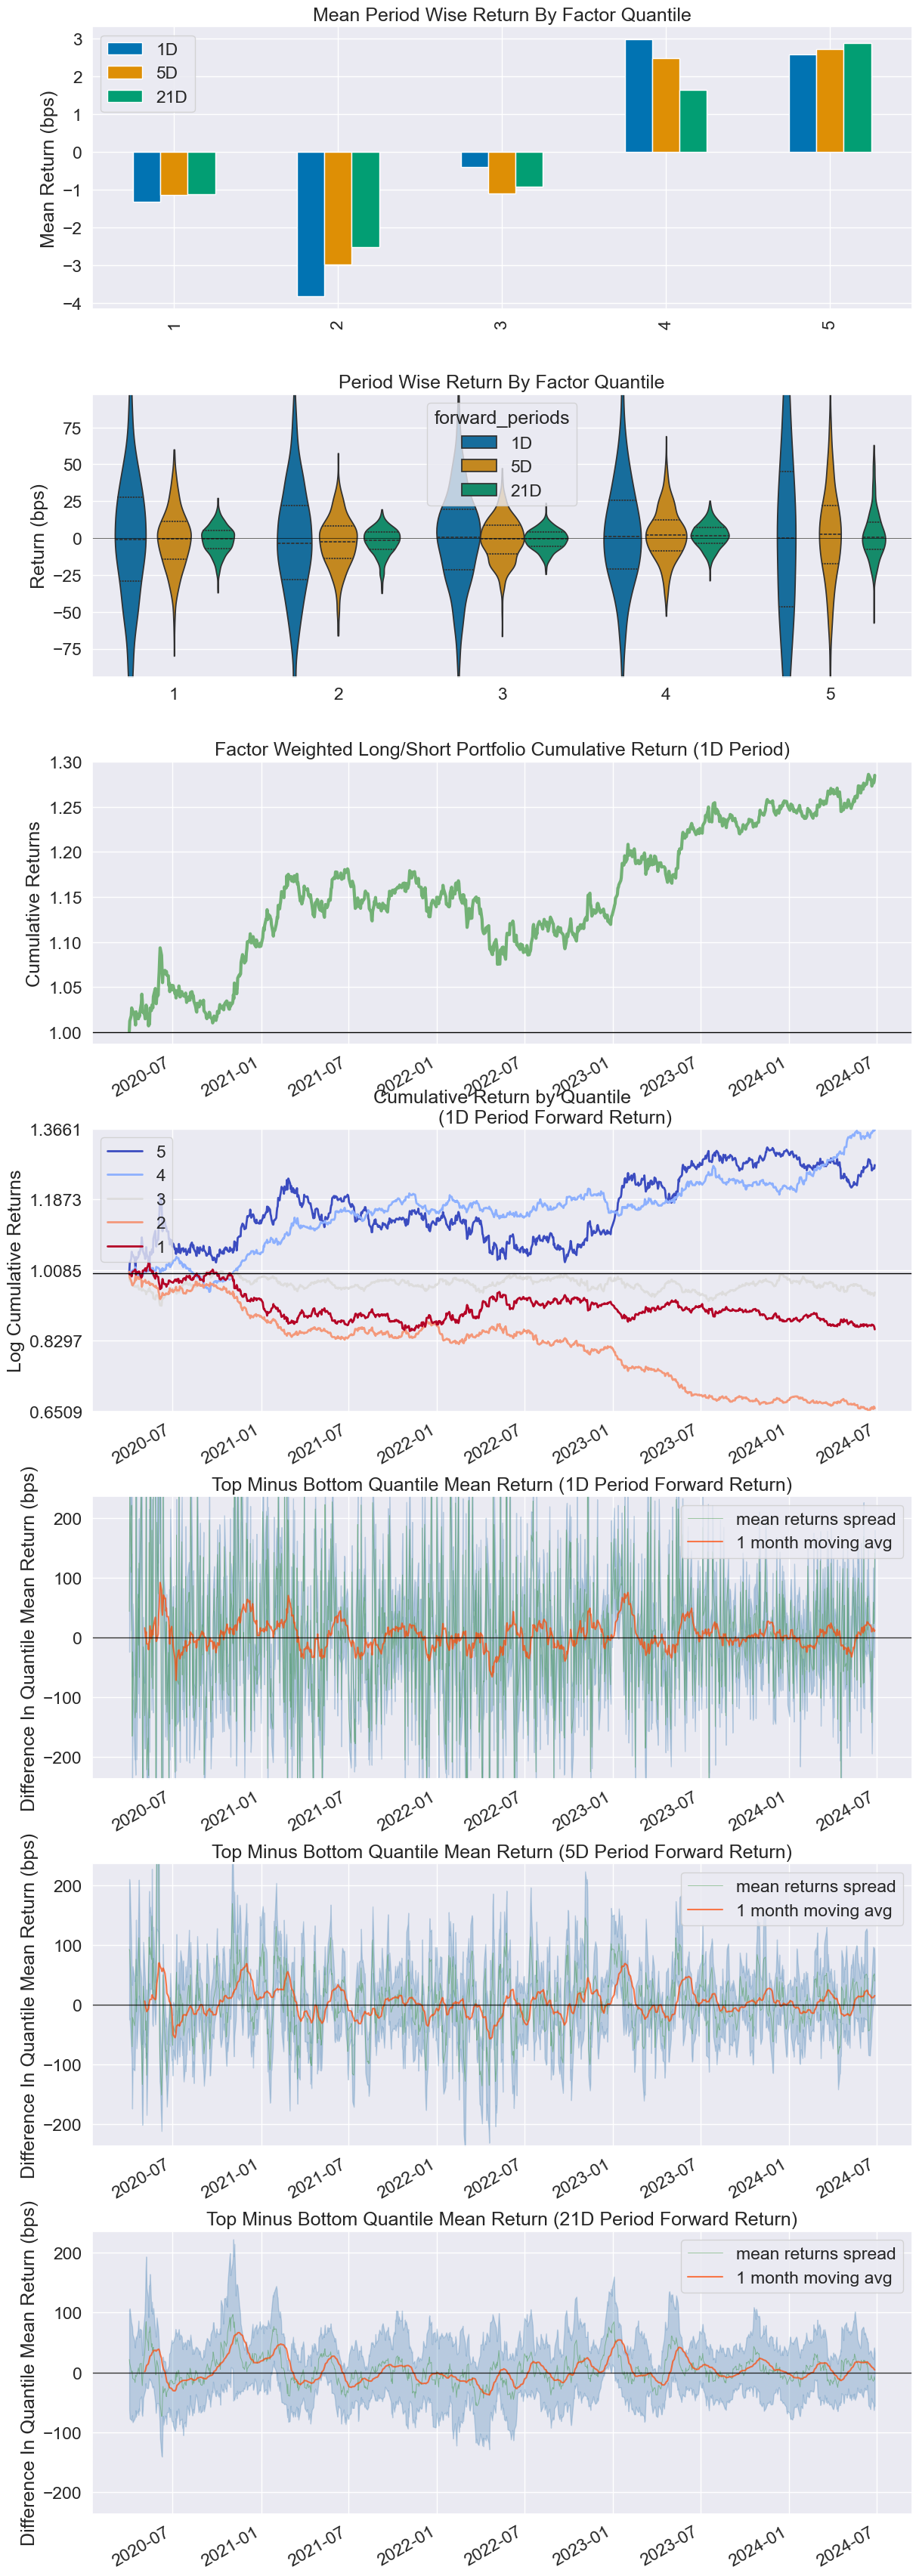

Information Analysis


,1D,5D,21D
IC Mean,-0.0020,0.0060,0.0180
IC Std.,0.2280,0.2200,0.2070
Risk-Adjusted IC,-0.0080,0.0270,0.0860
t-stat(IC),-0.2560,0.8970,2.8070
p-value(IC),0.7980,0.3700,0.0050
IC Skew,0.0220,-0.0840,0.0490
IC Kurtosis,-0.4910,-0.4680,-0.5800


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


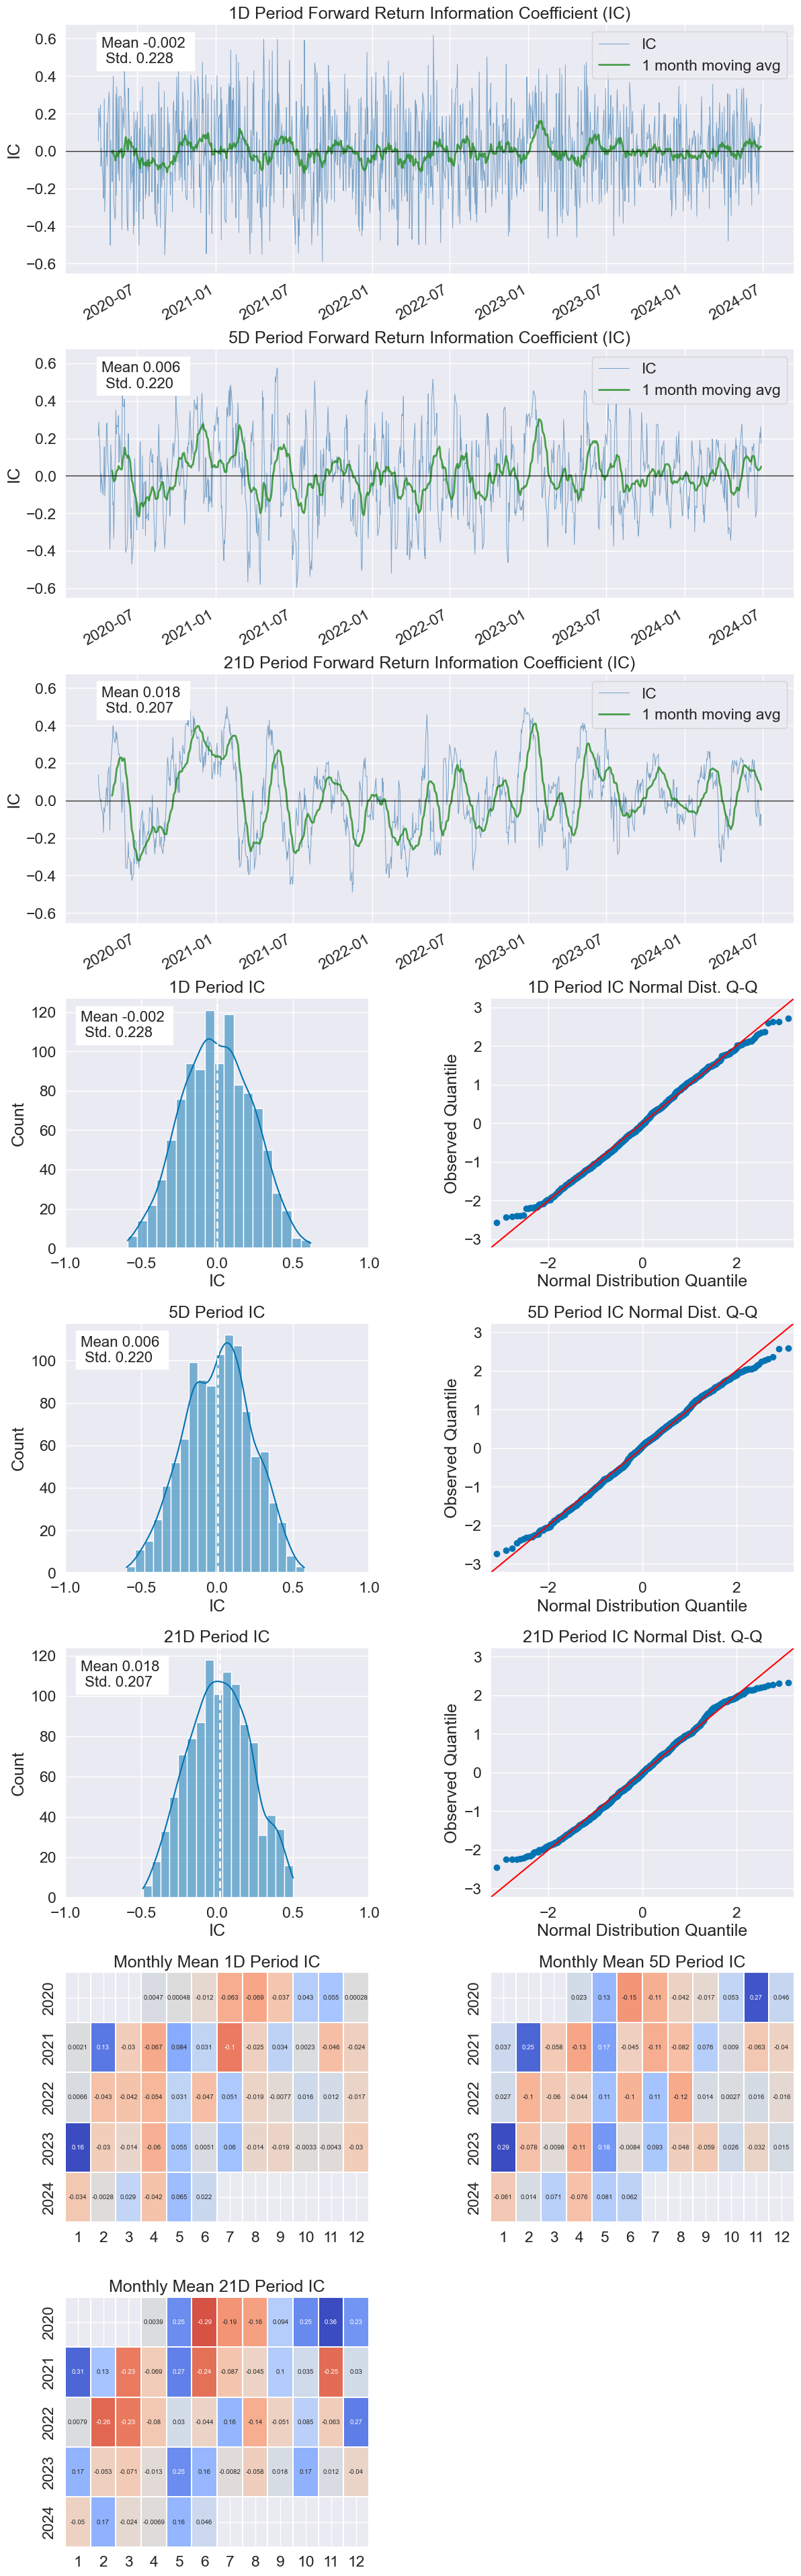

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,21D
Quantile 1 Mean Turnover,0.0430,0.1100,0.2440
Quantile 2 Mean Turnover,0.0880,0.2220,0.4560
Quantile 3 Mean Turnover,0.0930,0.2350,0.5000
Quantile 4 Mean Turnover,0.0780,0.2010,0.4450
Quantile 5 Mean Turnover,0.0320,0.0900,0.2190


,1D,5D,21D
Mean Factor Rank Autocorrelation,0.9930,0.9690,0.8780


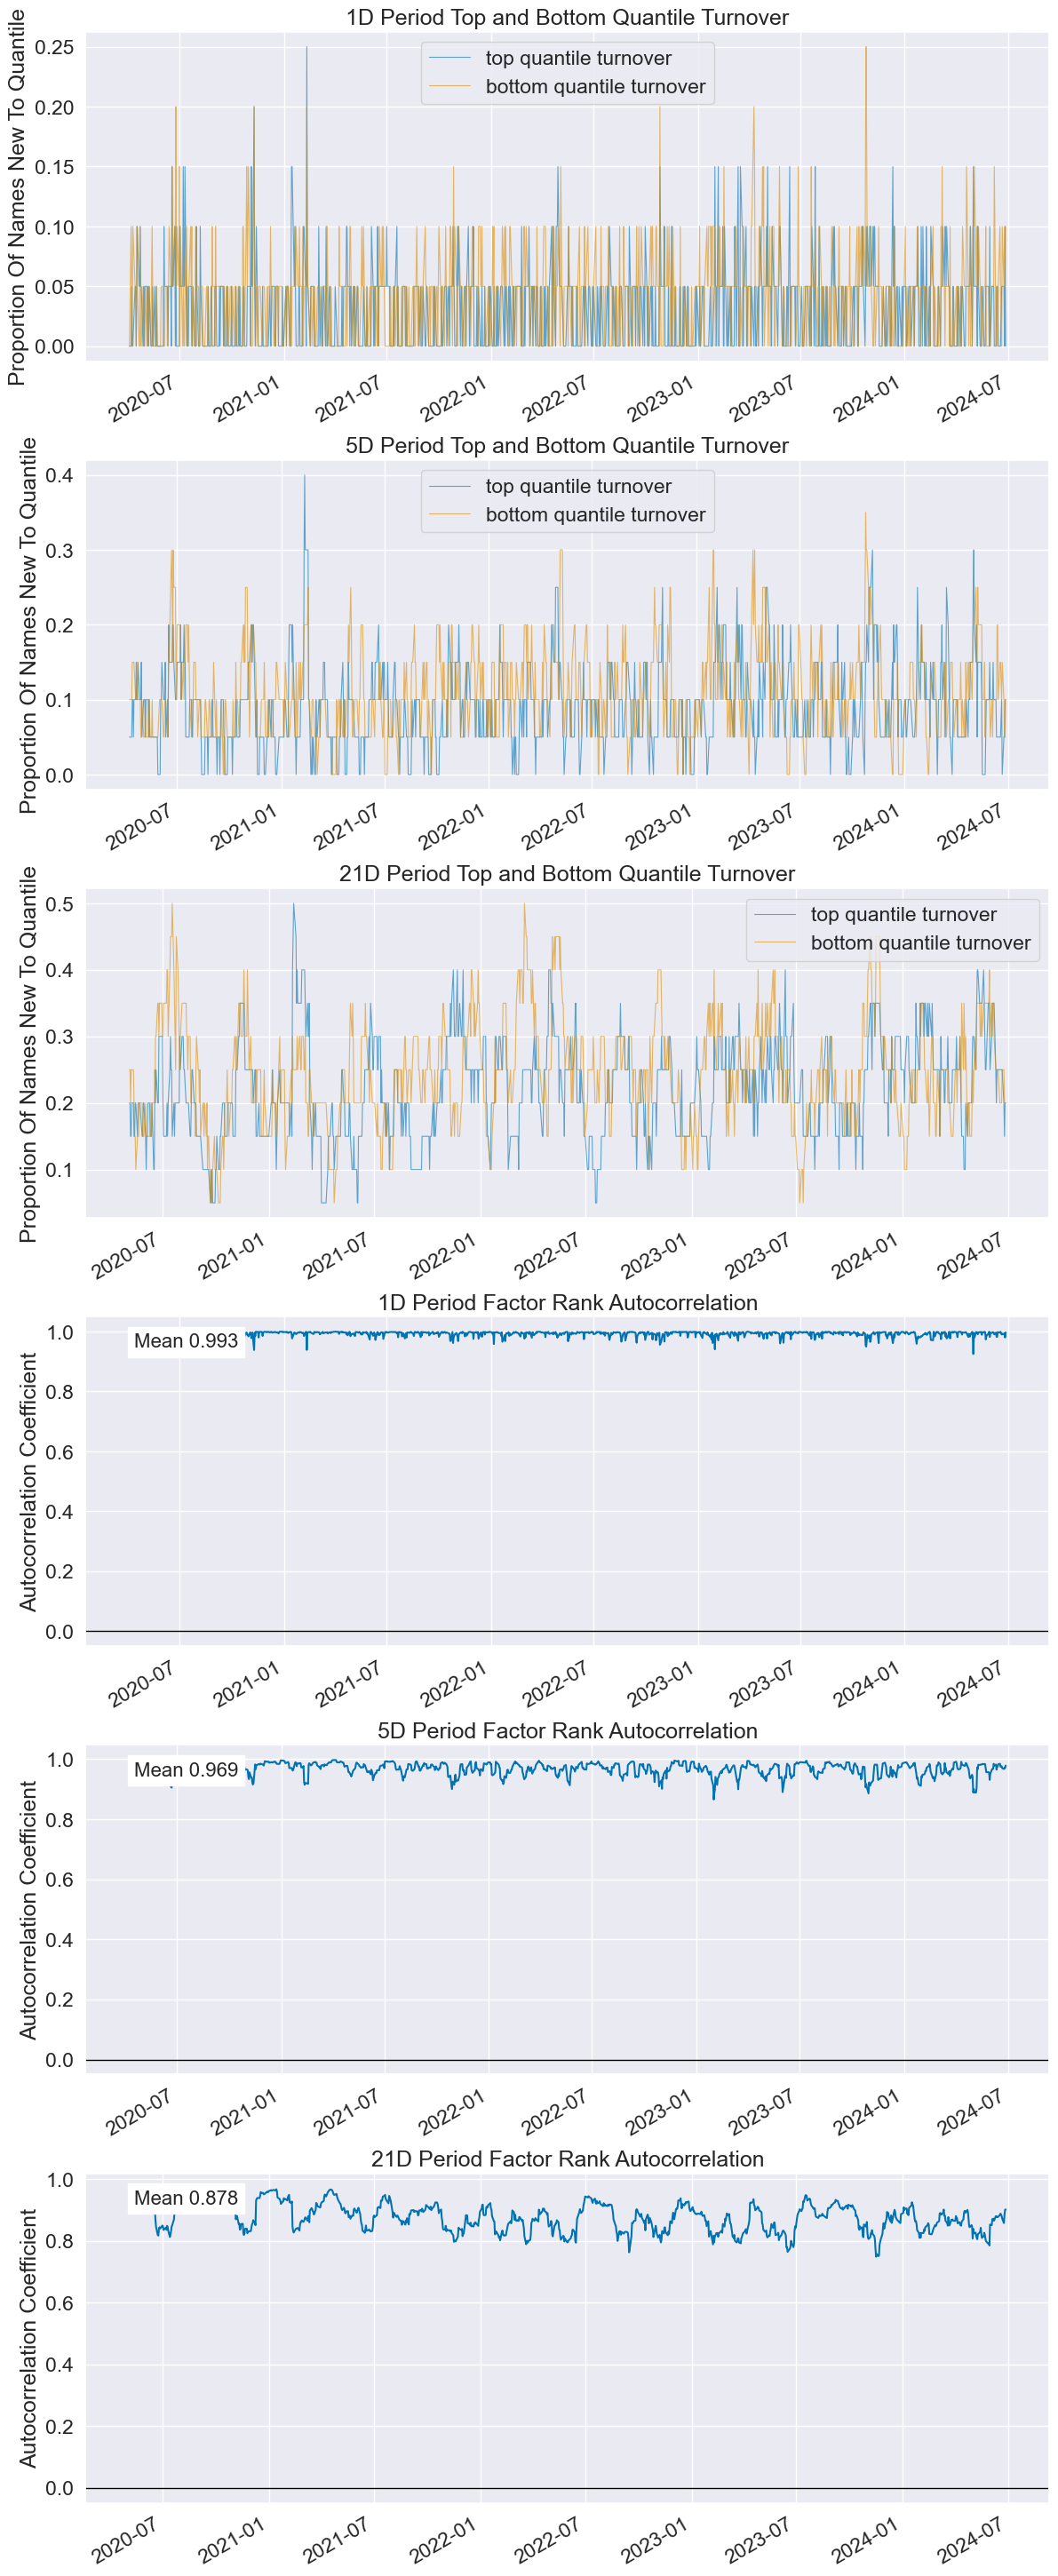

In [19]:
# --- Edit after reviewing the §4.1 summary table ---
TEAR_KIND = "idio"     # idio | realised
TEAR_WINDOW = 63       # W

tear_col = tear_factor_col(TEAR_KIND, TEAR_WINDOW)
print(f"Tear sheet factor: {tear_col}")
tear_factor_data = run_full_tear(panel, tear_col, prices)
